# Week 8 Capstone: consolidated GP-UCB review

## Table of contents

1. [Overview](#overview)
2. [Objectives](#objectives)
3. [Evidence provenance](#evidence-provenance)
4. [Environment and setup](#environment-setup)
5. [Data validation](#data-validation)
6. [Descriptive EDA](#descriptive-eda)
7. [Visual EDA](#visual-eda)
8. [GP model configuration](#gp-model-configuration)
9. [GP-UCB values](#gp-ucb-values)
10. [Reproducibility checks](#reproducibility-checks)
11. [Conclusions and next steps](#conclusions-next-steps)

<a id="overview"></a>
## 1. Overview

The Week 8 archive and returned Week 7 observations are unavailable. This notebook reviews all 199 verified observations, marks Weeks 3–5 and Week 7 pending, and replaces 138 stateful copy-pasted cells with a reproducible F1–F8 GP-UCB workflow.

<a id="objectives"></a>
## 2. Objectives

Validate the Week 8 evidence, review F1–F8, document the acquisition strategy, generate reproducible recommendations, and verify every output.

<a id="evidence-provenance"></a>
## 3. Evidence provenance

1. `/content/week_8_data.zip` is absent and all `/content` dataset paths fail.
2. `week8_queries.txt` is empty, so Week 7 returns cannot be recovered.
3. The 138-cell notebook repeats nearly identical logic per function, causing variable leakage (`X1`, `y1`, `dim`, `kappa`) and unsafe out-of-order execution.
4. Function 2 selects with its own UCB but reports `predicted_mean_1` and `predicted_std_1` from Function 1.
5. Function 8 silently executes `y8 = y8[:len(X8)]`, hiding mismatched data instead of validating it.
6. Function 8 fits two contradictory GPs and uses the second while displaying the first as the learned model.
7. Several models use fixed length scales without fitting hyperparameters, while others fit composite kernels; one consistent fitted model is now used.
8. `allow_pickle=True` unnecessarily accepts unsafe object arrays. Only numeric arrays are accepted.
9. Repeated `np.random.seed(42)` gives every function correlated candidate prefixes and makes state fragile. Function-specific generators are used.
10. Rounded proposals were not checked for duplicates, correlation heatmaps were overinterpreted as sensitivity, and the summary falsely called an absent dataset confirmed.
11. Scattered plots and statistics are consolidated into complete, comparable function diagnostics plus an overview.

<a id="environment-setup"></a>
## 4. Environment and setup

Initialise paths, dependencies, dimensions, evidence mappings, and reusable analysis helpers.

In [1]:
from pathlib import Path
import math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, Matern, WhiteKernel

FUNCTIONS=tuple(range(1,9)); DIMS={1:2,2:2,3:3,4:4,5:4,6:5,7:6,8:8}; KAPPA={1:1.5,2:2.,3:2.,4:2.,5:2.,6:2.,7:2.,8:2.}
EARLY_Q={1:[[.375440,.950714],[.536429,.835362]],2:[[.375440,.950714],[.978752,.932731]],3:[[.444444,.666666,.333333],[.657452,.998464,.817253]],4:[[.555555,.444444,.222222,.111111],[.006280,.281840,.932013,.960202]],5:[[.224189,.846480,.879484,.878515],[.255841,.841692,.888984,.860260]],6:[[.728186,.154693,.732552,.693997,.564013],[.433654,.486678,.282753,.972905,.323321]],7:[[.045091,.528666,.329265,.105350,.434667,.641164],[.243848,.900100,.696978,.193630,.374149,.826324]],8:[[.273673,.260400,.073937,.078562,.862321,.230729,.106880,.352588],[.163160,.184786,.152644,.083802,.999322,.544113,.184124,.123846]]}
EARLY_Y={1:[-1.560646704467778e-117,1.674933466363685e-36],2:[-.03182956281754251,.022666631114895516],3:[-.04090761844901528,-.08987474979637637],4:[-8.727516493155957,-31.73535839431216],5:[1088.8535114737463,1035.6341457754475],6:[-1.1520351120911565,-.8782405650300305],7:[1.0510148516295004,.308765180253091],8:[9.8157087929671,9.9399041910574]}
W6Q={1:[.897714,.081699],2:[.555332,.360931],3:[.522231,.090709,.451742],4:[.713766,.198601,.014095,.068347],5:[.754614,.504566,.432986,.307039],6:[.824244,.022732,.960907,.041715,.897560],7:[.052337,.910075,.727790,.075231,.386516,.492629],8:[.110992,.462977,.255313,.963757,.895383,.716713,.030436,.083412]}
W6Y={1:7.651210225556565e-239,2:.22078072799826579,3:-.05739710166867316,4:-17.92630659900679,5:.9401160531598542,6:-2.5293691850310744,7:.19078262729854223,8:9.1386093133071}
def find_root(start=None):
    p=Path.cwd() if start is None else Path(start).resolve()
    for c in (p,*p.parents):
        if (c/'Week_01').is_dir() and (c/'Week_08').is_dir(): return c
    raise FileNotFoundError('Repository root not found.')
ROOT=find_root(); plt.style.use('seaborn-v0_8-whitegrid'); print(f'Repository root: {ROOT}')

Matplotlib is building the font cache; this may take a moment.


Repository root: /Users/john-peteramewu/Documents/GitHub/My_Capstone_1_Imperial


In [2]:
def validate(fn,X,y):
    if X.ndim!=2 or X.shape[1]!=DIMS[fn]: raise ValueError(f'F{fn}: expected (*,{DIMS[fn]}), got {X.shape}.')
    if y.ndim!=1 or len(X)!=len(y) or not len(y): raise ValueError(f'F{fn}: input/output counts must match.')
    if X.dtype==object or y.dtype==object: raise TypeError(f'F{fn}: object arrays are rejected.')
    if not np.isfinite(X).all() or not np.isfinite(y).all(): raise ValueError(f'F{fn}: non-finite values found.')
    if np.any((X<0)|(X>1)): raise ValueError(f'F{fn}: inputs outside [0,1].')
def load_verified(fn):
    folder=ROOT/'Week_01'/f'Function_{fn:02d}'/'03_Data'; X=np.asarray(np.load(folder/'initial_inputs.npy',allow_pickle=False),float); y=np.asarray(np.load(folder/'initial_outputs.npy',allow_pickle=False),float).reshape(-1); validate(fn,X,y)
    for q,v in zip(EARLY_Q[fn],EARLY_Y[fn]): X=np.vstack((X,np.asarray(q,float))); y=np.append(y,v)
    q6=np.asarray(W6Q[fn],float)
    if q6.shape!=(DIMS[fn],): raise ValueError(f'F{fn}: wrong Week 6 dimension.')
    X=np.vstack((X,q6)); y=np.append(y,W6Y[fn]); validate(fn,X,y); return X,y

<a id="data-validation"></a>
## 5. Data validation

Apply the notebook's shape, bounds, finiteness, alignment, and evidence-count checks before interpretation.

<a id="descriptive-eda"></a>
## 6. Descriptive EDA

The latest recoverable observation is the Week 6 return recorded in Week 7. Weeks 3–5 and Week 7 remain pending.

In [3]:
def summarize(fn):
    X,y=load_verified(fn); previous=y[:-1]; best=int(np.argmax(y))
    return {'Function':f'F{fn}','Dimensions':DIMS[fn],'Verified observations':len(y),'Minimum':float(np.min(y)),'Mean':float(np.mean(y)),'Previous best':float(np.max(previous)),'Latest recoverable':float(y[-1]),'Verified best':float(y[best]),'Latest improvement':float(np.max(y)-np.max(previous)),'Latest percentile':100*float(np.mean(previous<=y[-1])),'Best query':best+1,'Best input':X[best].tolist(),'Evidence gaps':'Weeks 3–5 and Week 7 pending'}
performance=pd.DataFrame([summarize(i) for i in FUNCTIONS]); performance

,Function,Dimensions,Verified observations,Minimum,Mean,Previous best,Latest recoverable,Verified best,Latest improvement,Latest percentile,Best query,Best input,Evidence gaps
0,F1,2,13,-0.003606,-0.000277,7.710875e-16,7.651210e-239,7.710875e-16,0.0,33.333333,3,"[0.7310236309563586, 0.7329998764152272]",Weeks 3–5 and Week 7 pending
1,F2,2,13,-0.065624,0.193720,6.112052e-01,2.207807e-01,6.112052e-01,0.0,58.333333,10,"[0.7026365569244406, 0.9265641975455574]",Weeks 3–5 and Week 7 pending
2,F3,3,18,-0.398926,-0.099760,-3.483531e-02,-5.739710e-02,-3.483531e-02,0.0,64.705882,4,"[0.49258141463713434, 0.6115931882759961, 0.34...",Weeks 3–5 and Week 7 pending
3,F4,4,33,-32.625660,-17.440812,-4.025542e+00,-1.792631e+01,-4.025542e+00,0.0,34.375000,28,"[0.5777656143780968, 0.4287717415443063, 0.425...",Weeks 3–5 and Week 7 pending
4,F5,4,23,0.112940,223.950665,1.088860e+03,9.401161e-01,1.088860e+03,0.0,4.545455,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",Weeks 3–5 and Week 7 pending
5,F6,5,23,-2.571170,-1.498585,-7.142649e-01,-2.529369e+00,-7.142649e-01,0.0,4.545455,1,"[0.7281861047460138, 0.1546925696237983, 0.732...",Weeks 3–5 and Week 7 pending
6,F7,6,33,0.002701,0.246629,1.364968e+00,1.907826e-01,1.364968e+00,0.0,59.375000,7,"[0.057895541971385245, 0.49167221863901367, 0....",Weeks 3–5 and Week 7 pending
7,F8,8,43,5.592193,7.941981,9.939904e+00,9.138609e+00,9.939904e+00,0.0,85.714286,42,"[0.16316, 0.184786, 0.152644, 0.083802, 0.9993...",Weeks 3–5 and Week 7 pending


In [4]:
for r in performance.to_dict('records'):
    status='IMPROVED' if r['Latest improvement']>0 else 'NO NEW BEST'
    print(f"{r['Function']} — GP-UCB — {status}")
    print(f"  verified observations={r['Verified observations']}, dimensions={r['Dimensions']}")
    print(f"  previous={r['Previous best']:.12g}, latest={r['Latest recoverable']:.12g}, best={r['Verified best']:.12g}")
    print(f"  evidence gaps: {r['Evidence gaps']}")

F1 — GP-UCB — NO NEW BEST
  verified observations=13, dimensions=2
  previous=7.7108751145e-16, latest=7.65121022556e-239, best=7.7108751145e-16
  evidence gaps: Weeks 3–5 and Week 7 pending
F2 — GP-UCB — NO NEW BEST
  verified observations=13, dimensions=2
  previous=0.611205215761, latest=0.220780727998, best=0.611205215761
  evidence gaps: Weeks 3–5 and Week 7 pending
F3 — GP-UCB — NO NEW BEST
  verified observations=18, dimensions=3
  previous=-0.0348353133501, latest=-0.0573971016687, best=-0.0348353133501
  evidence gaps: Weeks 3–5 and Week 7 pending
F4 — GP-UCB — NO NEW BEST
  verified observations=33, dimensions=4
  previous=-4.02554228191, latest=-17.926306599, best=-4.02554228191
  evidence gaps: Weeks 3–5 and Week 7 pending
F5 — GP-UCB — NO NEW BEST
  verified observations=23, dimensions=4
  previous=1088.8596182, latest=0.94011605316, best=1088.8596182
  evidence gaps: Weeks 3–5 and Week 7 pending
F6 — GP-UCB — NO NEW BEST
  verified observations=23, dimensions=5
  previous

<a id="visual-eda"></a>
## 7. Visual EDA

Review the observed trajectories and diagnostic intent before fitting the next-query model.

<a id="gp-model-configuration"></a>
## 8. GP model configuration

Each function uses one fitted composite GP, 10,000 reproducible candidates, and its own UCB diagnostics. F1 keeps κ=1.5; the other functions use κ=2.

In [5]:
def propose(fn,X,y,rng,n=10000):
    d=X.shape[1]; base=RBF(np.ones(d),(1e-2,1e2)) if fn==1 else Matern(np.ones(d),(1e-2,1e2),nu=1.5 if fn==8 else 2.5)
    kernel=ConstantKernel(1.,(1e-3,1e3))*base+WhiteKernel(1e-5,(1e-10,1e1)); gp=GaussianProcessRegressor(kernel=kernel,normalize_y=True,n_restarts_optimizer=3,random_state=42)
    with warnings.catch_warnings(): warnings.simplefilter('ignore',ConvergenceWarning); gp.fit(X,y)
    points=rng.uniform(0,1,(n,d)); mean,std=gp.predict(points,return_std=True); ucb=mean+KAPPA[fn]*std
    for idx in np.argsort(ucb)[::-1]:
        q=np.round(points[idx],6)
        if not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1)):
            return {'query':q,'kernel':str(gp.kernel_),'mean':float(mean[idx]),'std':float(std[idx]),'ucb':float(ucb[idx])}
    raise RuntimeError('No distinct proposal.')

<a id="gp-ucb-values"></a>
## 9. GP-UCB values

Generate and display the exact proposed queries, fitted kernels, predictive uncertainty, and acquisition values, followed by their supporting diagnostics.

In [6]:
week8_queries,rows={},[]
for fn in FUNCTIONS:
    X,y=load_verified(fn); result=propose(fn,X,y,np.random.default_rng(800+fn)); q=result['query']; week8_queries[fn]=q
    rows.append({'Function':f'F{fn}','Kappa':KAPPA[fn],'Proposed query':q.tolist(),'Fitted kernel':result['kernel'],'Predictive mean':result['mean'],'Predictive std':result['std'],'UCB score':result['ucb'],'Distance from best':float(np.linalg.norm(q-X[int(np.argmax(y))]))})
proposal_summary=pd.DataFrame(rows); proposal_summary

,Function,Kappa,Proposed query,Fitted kernel,Predictive mean,Predictive std,UCB score,Distance from best
0,F1,1.5,"[0.969252, 0.207059]","1.05**2 * RBF(length_scale=[100, 0.0313]) + Wh...",-0.000183,0.000980,0.001287,0.577379
1,F2,2.0,"[0.732242, 0.220049]","0.974**2 * Matern(length_scale=[0.0437, 69.6],...",0.456432,0.148586,0.753605,0.707135
2,F3,2.0,"[0.359338, 0.085188, 8e-05]","1.69**2 * Matern(length_scale=[100, 100, 0.111...",-0.042081,0.077672,0.113263,0.640720
3,F4,2.0,"[0.405919, 0.476046, 0.359955, 0.458522]","4.74**2 * Matern(length_scale=[2.08, 1.89, 2.0...",-2.119027,0.755168,-0.608691,0.282845
4,F5,2.0,"[0.420057, 0.578575, 0.995926, 0.999925]","2.09**2 * Matern(length_scale=[100, 16.5, 1.04...",1637.826462,127.469304,1892.765069,0.372071
5,F6,2.0,"[0.503553, 0.009381, 0.918887, 0.995723, 0.060...","1.63**2 * Matern(length_scale=[0.51, 1.15, 1.3...",-0.458260,0.340325,0.222390,0.444244
6,F7,2.0,"[0.000773, 0.421651, 0.779217, 0.324821, 0.340...","0.965**2 * Matern(length_scale=[0.968, 0.363, ...",1.242908,0.166031,1.574969,0.574371
7,F8,2.0,"[0.103615, 0.088681, 0.239834, 0.043935, 0.723...","5.28**2 * Matern(length_scale=[5.86, 9.75, 4.8...",9.868447,0.127990,10.124427,0.882954


Red diamonds mark the latest recoverable observation and gold stars the verified optimum. Feature panels are coloured by verified query order.

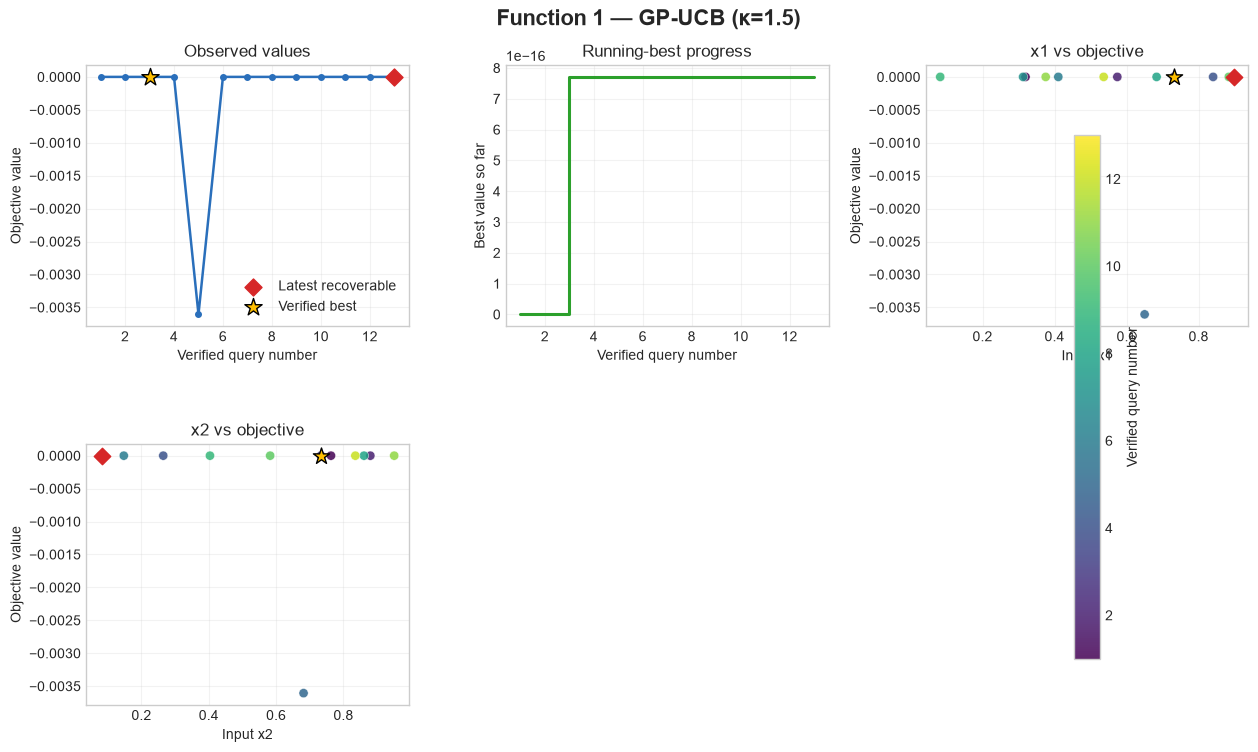

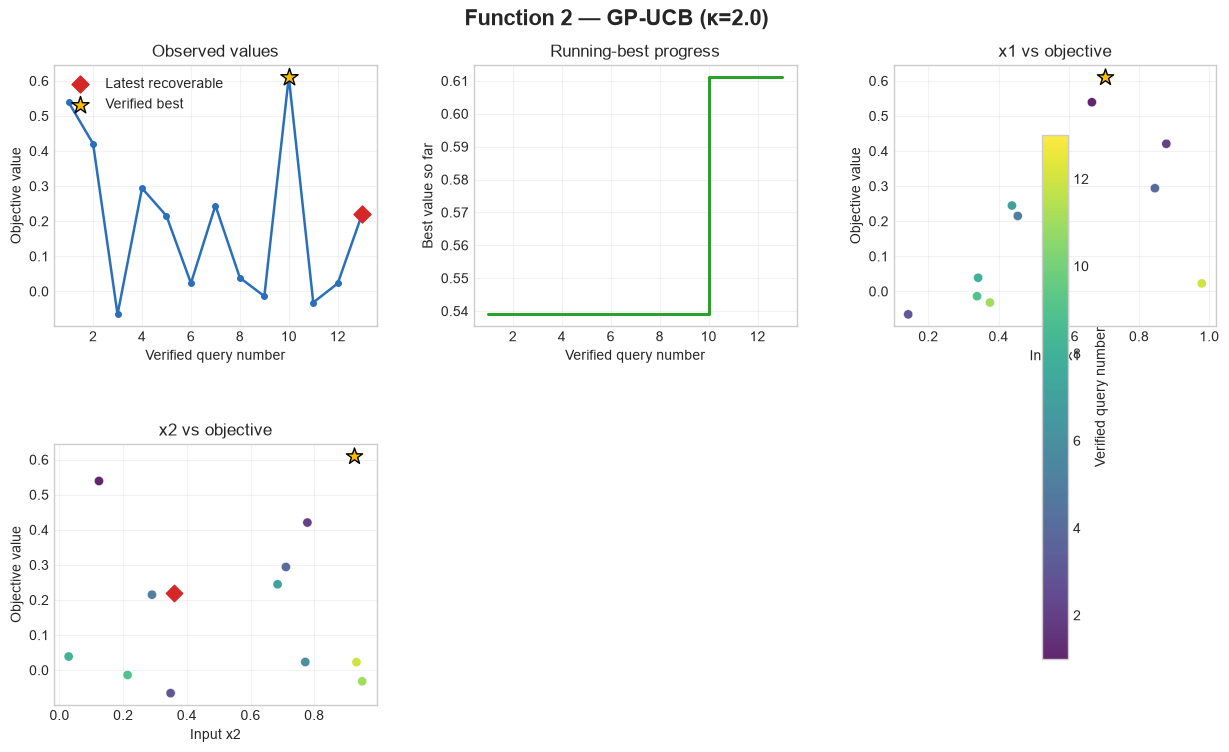

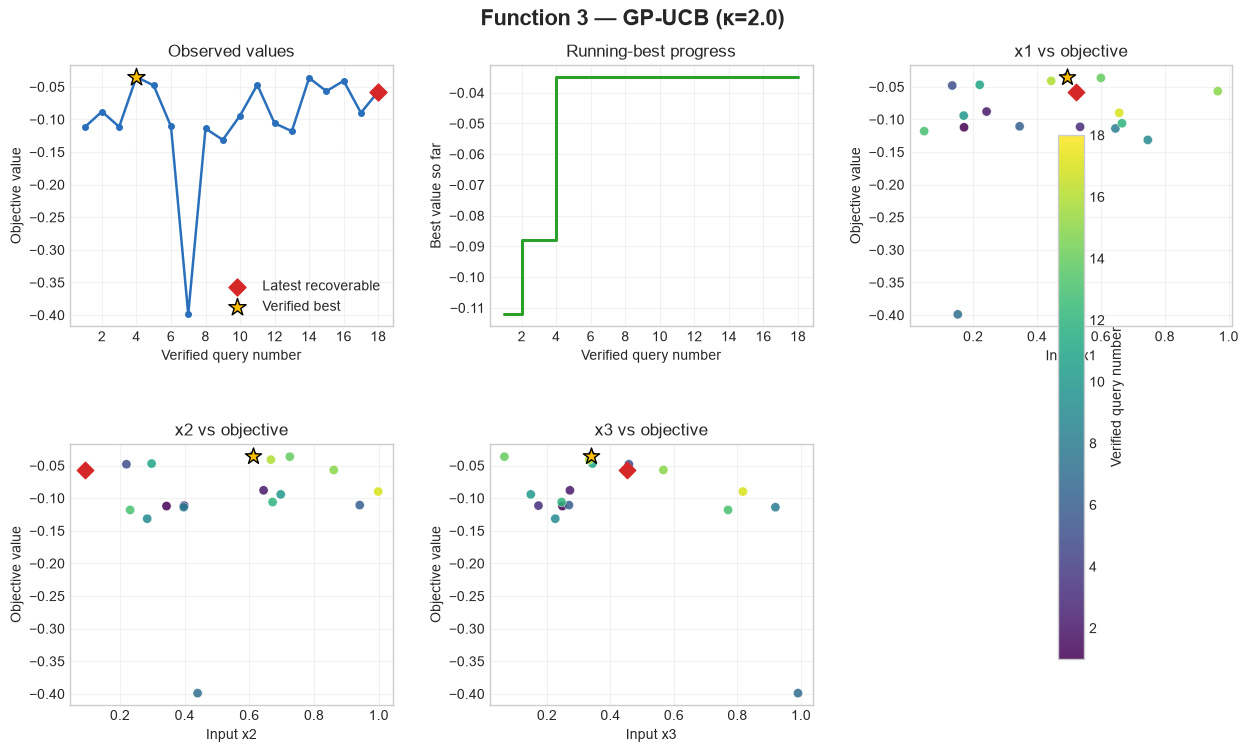

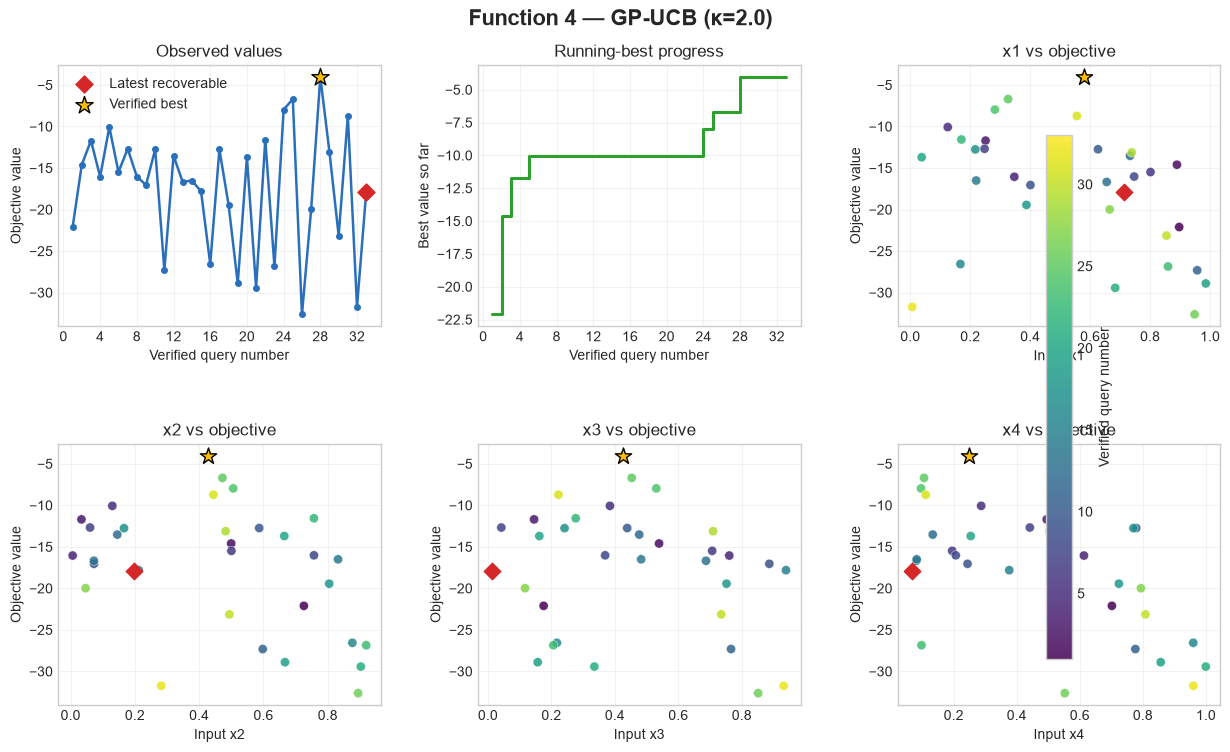

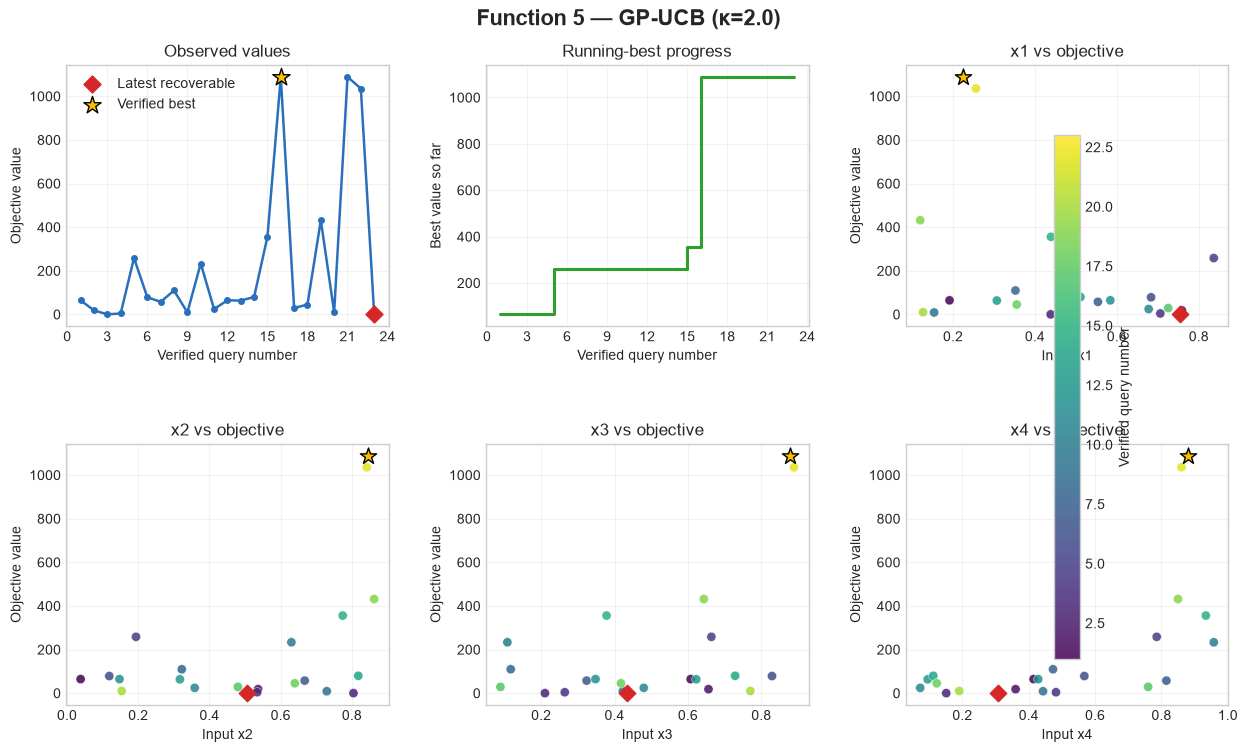

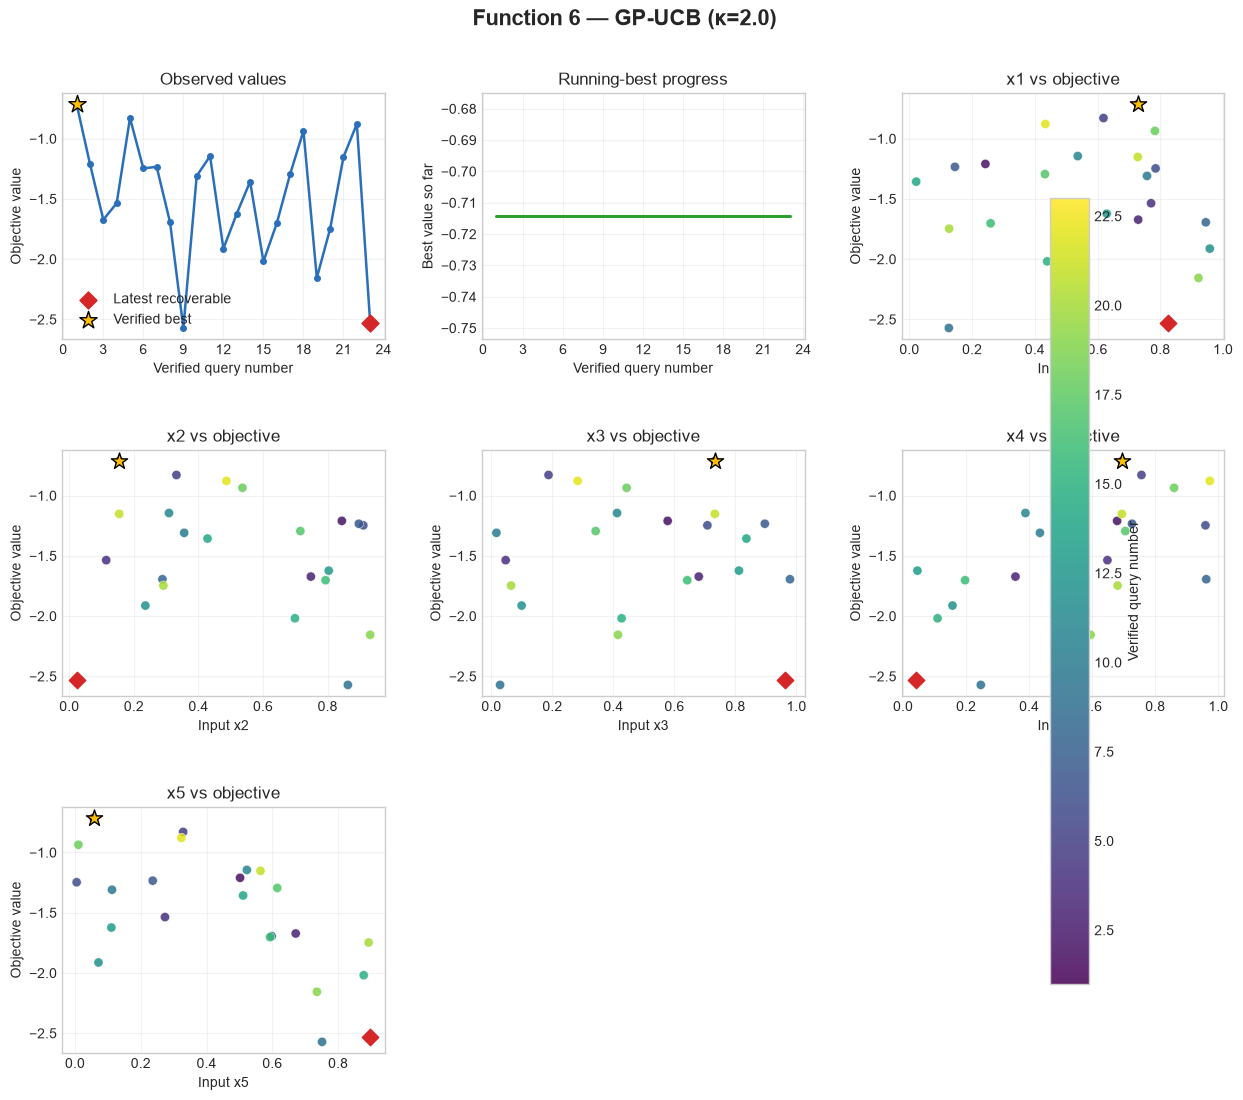

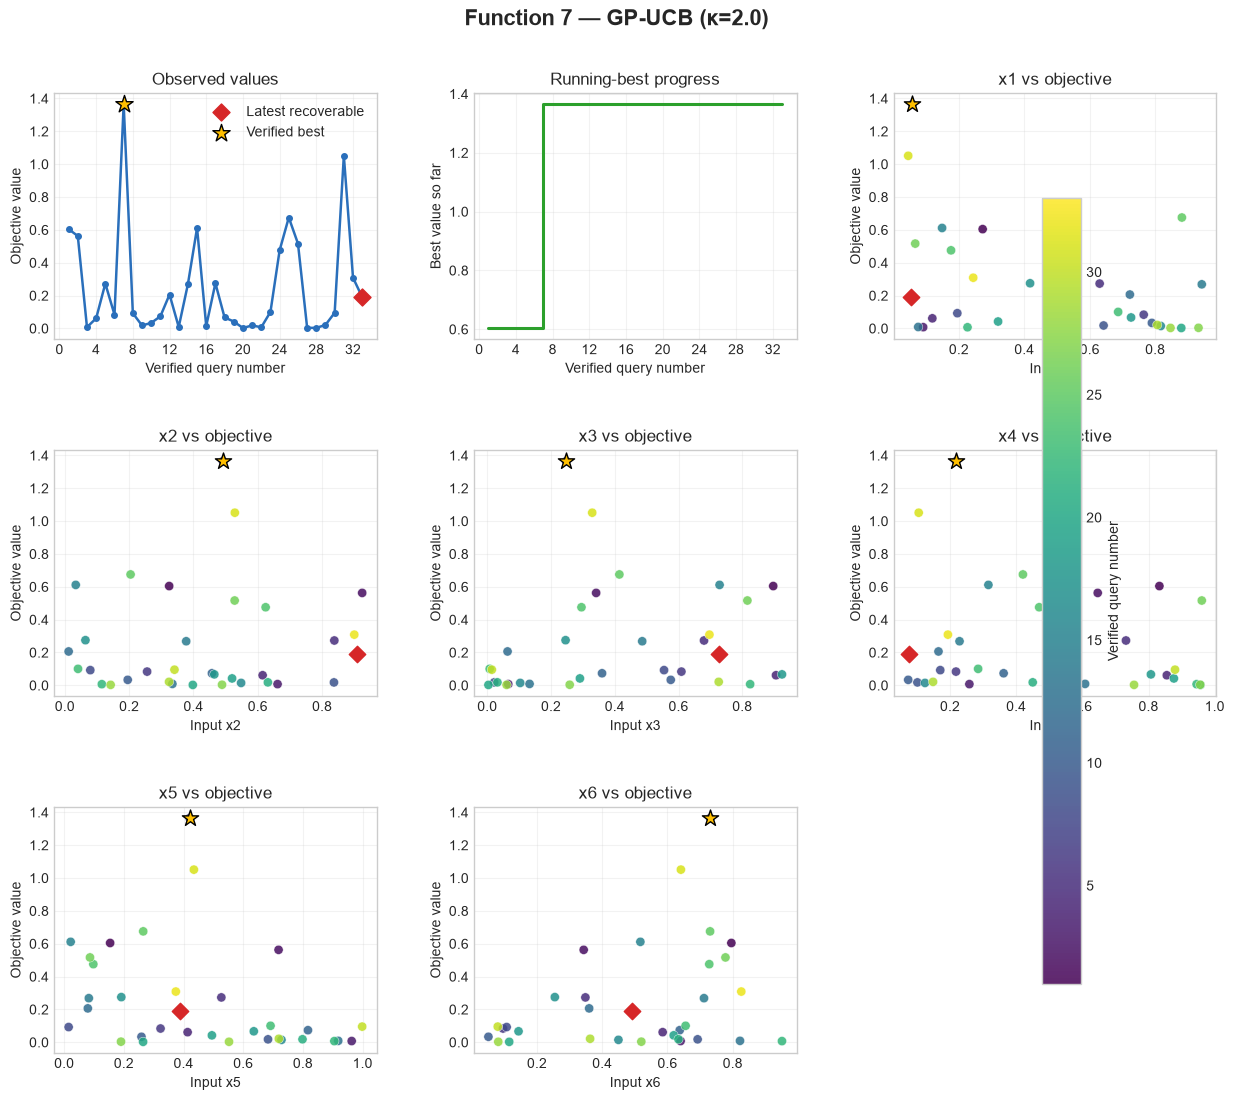

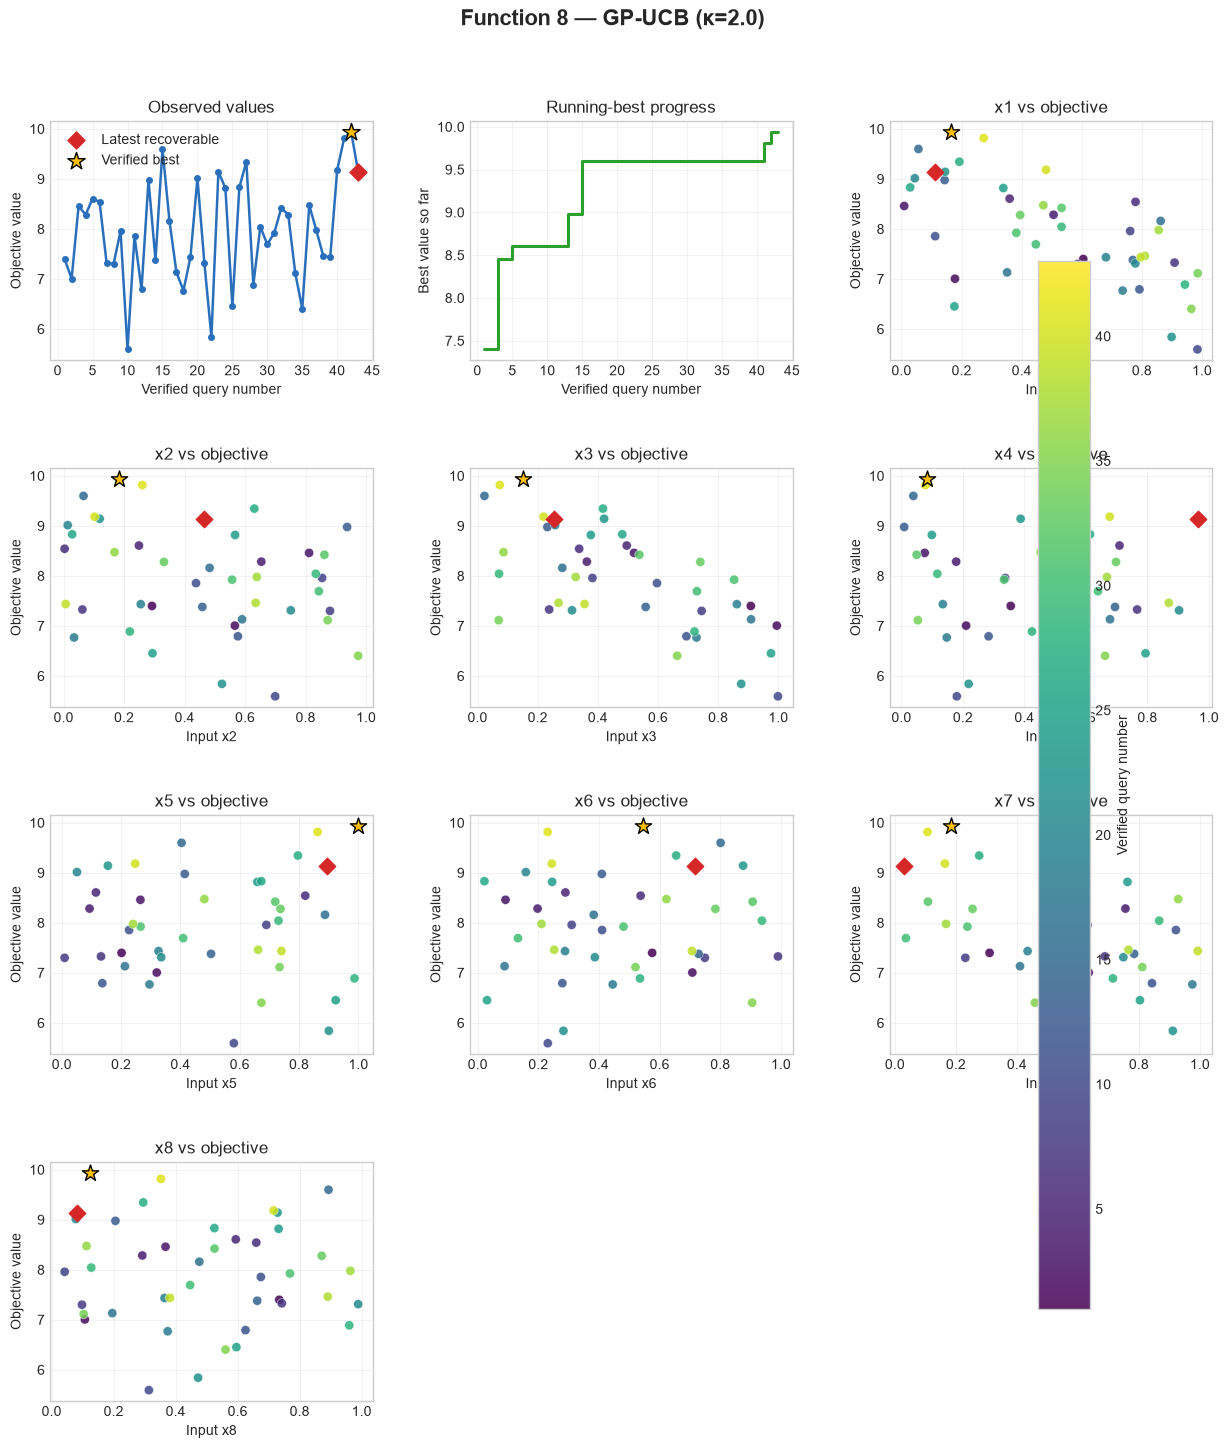

Rendered 8 function diagnostic figures.


In [7]:
def plot_function(fn):
    X,y=load_verified(fn); q=np.arange(1,len(y)+1); best=int(np.argmax(y)); panels=X.shape[1]+2; cols=3; rows=math.ceil(panels/cols); fig,axes=plt.subplots(rows,cols,figsize=(15,4*rows),squeeze=False); axes=axes.ravel()
    axes[0].plot(q,y,color='#2a6fbb',marker='o',lw=1.8,ms=4); axes[0].scatter(q[-1],y[-1],marker='D',color='#d62728',s=75,zorder=4,label='Latest recoverable'); axes[0].scatter(q[best],y[best],marker='*',color='#ffbf00',edgecolor='black',s=170,zorder=5,label='Verified best'); axes[0].set(xlabel='Verified query number',ylabel='Objective value',title='Observed values'); axes[0].legend(); axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[1].step(q,np.maximum.accumulate(y),where='post',color='#2ca02c',lw=2.2); axes[1].set(xlabel='Verified query number',ylabel='Best value so far',title='Running-best progress'); axes[1].xaxis.set_major_locator(MaxNLocator(integer=True)); colour=None
    for col,axis in enumerate(axes[2:2+X.shape[1]]): colour=axis.scatter(X[:,col],y,c=q,cmap='viridis',s=44,alpha=.85,edgecolor='white',lw=.35); axis.scatter(X[-1,col],y[-1],marker='D',color='#d62728',s=70,zorder=4); axis.scatter(X[best,col],y[best],marker='*',color='#ffbf00',edgecolor='black',s=150,zorder=5); axis.set(xlabel=f'Input x{col+1}',ylabel='Objective value',title=f'x{col+1} vs objective')
    for axis in axes[panels:]: axis.set_visible(False)
    for axis in axes[:panels]: axis.grid(True,alpha=.25)
    fig.colorbar(colour,ax=axes[2:2+X.shape[1]].tolist(),label='Verified query number',shrink=.85); fig.suptitle(f'Function {fn} — GP-UCB (κ={KAPPA[fn]})',fontsize=16,fontweight='bold'); fig.subplots_adjust(top=.91,hspace=.45,wspace=.30); return fig
figures=[plot_function(i) for i in FUNCTIONS]; plt.show(); print(f'Rendered {len(figures)} function diagnostic figures.')

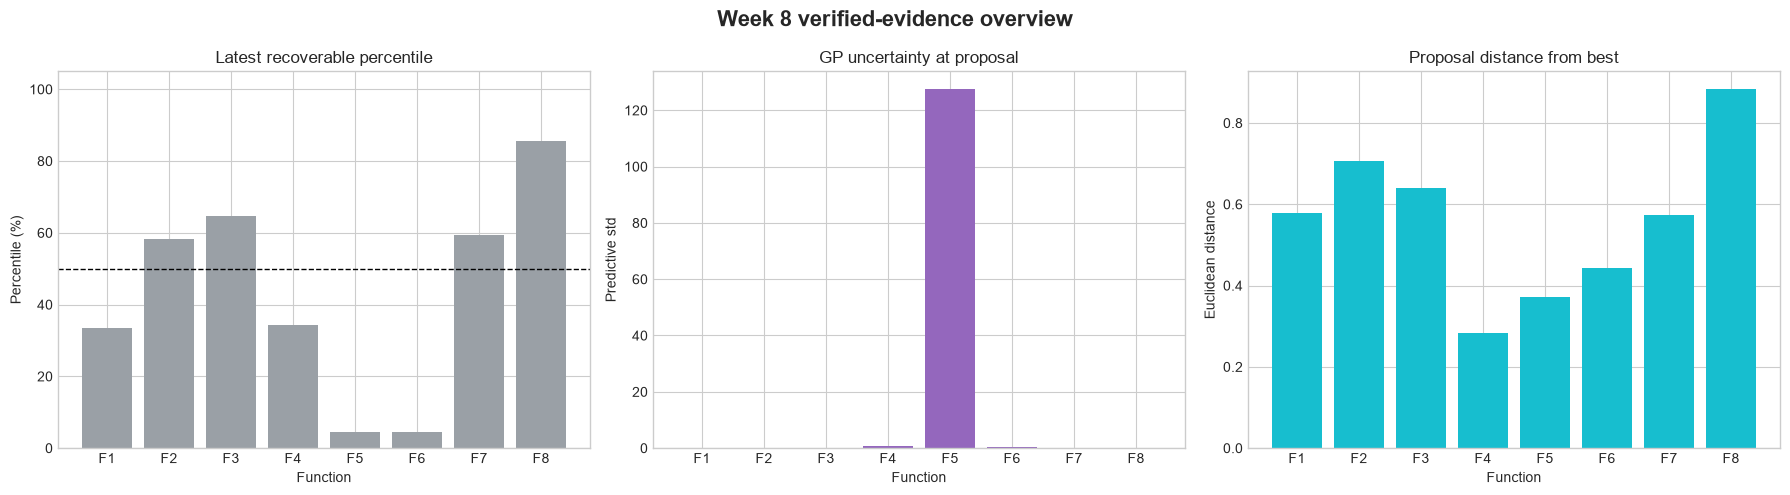

In [8]:
fig,axes=plt.subplots(1,3,figsize=(18,5)); colours=np.where(performance['Latest improvement']>0,'#2ca02c','#9aa0a6')
axes[0].bar(performance['Function'],performance['Latest percentile'],color=colours); axes[0].axhline(50,color='black',ls='--',lw=1); axes[0].set(title='Latest recoverable percentile',xlabel='Function',ylabel='Percentile (%)',ylim=(0,105))
axes[1].bar(proposal_summary['Function'],proposal_summary['Predictive std'],color='#9467bd'); axes[1].set(title='GP uncertainty at proposal',xlabel='Function',ylabel='Predictive std')
axes[2].bar(proposal_summary['Function'],proposal_summary['Distance from best'],color='#17becf'); axes[2].set(title='Proposal distance from best',xlabel='Function',ylabel='Euclidean distance')
fig.suptitle('Week 8 verified-evidence overview',fontsize=16,fontweight='bold'); fig.tight_layout(); plt.show()

<a id="reproducibility-checks"></a>
## 10. Reproducibility checks

In [9]:
expected={1:13,2:13,3:18,4:33,5:23,6:23,7:33,8:43}
for fn in FUNCTIONS:
    X,y=load_verified(fn); s=summarize(fn); q=week8_queries[fn]
    assert X.shape==(expected[fn],DIMS[fn]) and y.shape==(expected[fn],) and X.dtype!=object and y.dtype!=object
    assert np.allclose(X[-1],W6Q[fn]) and np.isclose(y[-1],W6Y[fn]) and s['Best query']==int(np.argmax(y))+1 and s['Latest improvement']>=0
    assert q.shape==(DIMS[fn],) and np.all((q>=0)&(q<=1)) and not np.any(np.all(np.isclose(X,q,rtol=0,atol=5e-7),axis=1))
assert sum(expected.values())==199 and len(performance)==len(proposal_summary)==len(week8_queries)==8
assert performance['Evidence gaps'].eq('Weeks 3–5 and Week 7 pending').all()
print('All Week 8 verified-data, performance, GP-UCB proposal, and plotting checks passed.')

All Week 8 verified-data, performance, GP-UCB proposal, and plotting checks passed.


<a id="conclusions-next-steps"></a>
## 11. Conclusions and next steps

The validated Week 8 workflow preserves observed evidence separately from proposed next queries and provides the handoff to the following round.